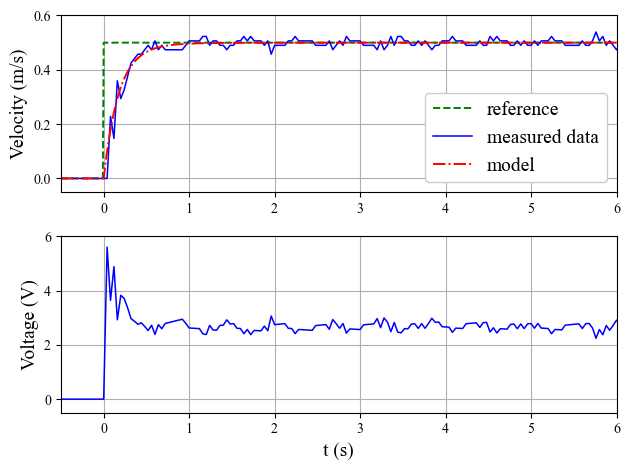

In [1]:
import numpy as np
import control as ctrl
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "pdf.fonttype": 42  # importante para compatibilidade IEEE
})

# =========================
# Leitura dos dados
# =========================
data = np.loadtxt('serial.txt')

final = 360
inicio = 100

# MATLAB: data(inicio:final, :)
# Python: índice inicial é 0 e o final é exclusivo
dados = data[inicio-1:final, :]

wheel_speed = dados[:, 0]
entrada = dados[:, 1]
tempo = dados[:, 2] - 9.09

# =========================
# Modelo planta + controlador PI
# =========================
k = 0.18
tau = 0.32

M = ctrl.tf([k], [tau, 1])

kp = 10
ki = 30
C = ctrl.tf([kp, ki], [1, 0])

F = ctrl.feedback(C * M, 1)

# Resposta ao degrau de amplitude 0.5 por 10 s
resp_t, y = ctrl.step_response(0.5 * F, T=np.linspace(0, 10, 1000))

# Prepend dos pontos iniciais, igual ao MATLAB
t = np.concatenate((np.array([-3.0, -0.01]), resp_t))
y = np.concatenate((np.array([0.0, 0.0]), y))

r = np.zeros_like(t)
r[t >= 0] = 0.5

# =========================
# Figura
# =========================
plt.figure()

plt.subplot(2, 1, 1)
plt.plot(t, r, '--g', linewidth=1.4)
plt.plot(tempo, wheel_speed, '-b', linewidth=1.1)
plt.plot(t, y, '-.r', linewidth=1.4)
plt.ylabel('Velocity (m/s)', fontsize=14)
plt.legend(['reference', 'measured data', 'model'],
           loc='lower right', fontsize=14, framealpha=1.0)
plt.xlim([-0.5, 6])
plt.ylim([-0.05, 0.6])
plt.grid(True, alpha=1.0)

plt.subplot(2, 1, 2)
plt.plot(tempo, entrada, 'b', linewidth=1.1)
plt.grid(True, alpha=1.0)
plt.xlabel('t (s)', fontsize=14)
plt.ylabel('Voltage (V)', fontsize=14)
plt.xlim([-0.5, 6])
plt.ylim([-0.5, 6])

plt.tight_layout()

# Se quiser salvar:
plt.savefig('controle_vel.pdf',
            format='pdf',
            bbox_inches='tight',
            facecolor='white')

plt.show()